# Amazon Sales Dataset Analysis

## Mini Project Report

*Submitted By:* Rashi Bansal

*Program:* Summer Training Program 2026

*Domain:* Data Science

*Organization:* Chandigarh Engineering College, CGC University, Mohali

### Project Objective

The objective of this project is to analyze Amazon sales data and identify key sales trends, store performance, holiday impact, and factors affecting weekly sales. The analysis is performed using Python and its data analysis libraries, including Pandas, NumPy, Matplotlib, and Seaborn.

### Dataset Overview

The Amazon Sales Dataset contains historical sales transaction records of products sold on Amazon. It's used to analyze customer buying behavior, product performance, sales trends, and category-wise revenue. Great for e-commerce analytics + forecasting projects.

This project focuses on exploring the dataset, understanding sales patterns, comparing store performance, and visualizing business insights through data analysis techniques.

### Tools and Libraries Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Google Colab

***Prepared as part of the Data Science Summer Training Program 2026

# 1. Import libraries





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset

In [ ]:
amazon_sales = pd.read_csv("amazon.csv.xls")

# 3. Show all column names

In [ ]:
print(amazon_sales.columns)

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')


# 4. How many products are available?

In [ ]:
total_products = amazon_sales["product_id"].nunique()
print("Total Products : ",total_products)

Total Products :  1351


# 5. Print all unique categories available in the category column

In [ ]:
print(amazon_sales["category"].unique)

<bound method Series.unique of 0       Computers&Accessories|Accessories&Peripherals|...
1       Computers&Accessories|Accessories&Peripherals|...
2       Computers&Accessories|Accessories&Peripherals|...
3       Computers&Accessories|Accessories&Peripherals|...
4       Computers&Accessories|Accessories&Peripherals|...
                              ...                        
1460    Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...
1461    Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...
1462    Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...
1463    Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...
1464    Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...
Name: category, Length: 1465, dtype: object>


# 6. Count products in each category

In [ ]:
category_counts = amazon_sales["category"].value_counts()
print(category_counts)

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                                          233
Electronics|WearableTechnology|SmartWatches                                                                                 76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                                        68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                                               63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                                                52
                                                                                                                          ... 
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|RotiMakers                                                        1
Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories                        

# 7. Which category has the most products?

In [ ]:
print(category_counts.head(10))

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                        233
Electronics|WearableTechnology|SmartWatches                                                               76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                      68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                             63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                              52
Electronics|HomeTheater,TV&Video|Accessories|RemoteControls                                               49
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders                                  27
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice                            24
Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables                                            24
Home&Kitch

# 8. Average Rating of Products

In [ ]:
amazon_sales["rating"] = pd.to_numeric(amazon_sales["rating"],errors="coerce")
avg_rating = amazon_sales["rating"].mean()
print("Average Rating : ",round(avg_rating,2))

Average Rating :  4.1


# 9. Top 10 Highest Rated Products

In [ ]:
top_rated = amazon_sales.sort_values(by="rating",ascending=False)[["product_name","rating"]].head(10)
print(top_rated)

                                           product_name  rating
174   Syncwire LTG to USB Cable for Fast Charging Co...     5.0
324   REDTECH USB-C to Lightning Cable 3.3FT, [Apple...     5.0
775   Amazon Basics Wireless Mouse | 2.4 GHz Connect...     5.0
1299  Instant Pot Air Fryer, Vortex 2QT, Touch Contr...     4.8
1201  Oratech Coffee Frother electric, milk frother ...     4.8
1145  Swiffer Instant Electric Water Heater Faucet T...     4.8
1223  FIGMENT Handheld Milk Frother Rechargeable, 3-...     4.7
1226  Zuvexa USB Rechargeable Electric Foam Maker - ...     4.7
1275  Multifunctional 2 in 1 Electric Egg Boiling St...     4.7
459   Spigen EZ Fit Tempered Glass Screen Protector ...     4.7


# 10. Products with Maximum Reviews

In [ ]:
top_reviews = amazon_sales.sort_values(by="rating_count",ascending=False)[["product_name","rating"]].head(10)
print(top_reviews)

                                           product_name  rating
1279  Eureka Forbes car Vac 100 Watts Powerful Sucti...     NaN
750        Eveready Red 1012 AAA Batteries - Pack of 10     4.3
977   Sennheiser CX 80S in-Ear Wired Headphones with...     4.1
1059  Pigeon 1.5 litre Hot Kettle and Stainless Stee...     3.7
151   Zoul USB Type C Fast Charging 3A Nylon Braided...     4.3
32    Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...     4.3
823   Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...     4.3
536   boAt Rockerz 400 Bluetooth On Ear Headphones W...     4.1
918   boAt Rockerz 400 Bluetooth On Ear Headphones W...     4.1
1165  Kitchenwell 18Pc Plastic Food Snack Bag Pouch ...     4.0


# 11. Calculate how much money customers save

In [ ]:
amazon_sales["savings"] = amazon_sales["actual_price"]-amazon_sales["discounted_price"]
amazon_sales[["product_name","savings"]].head()

,product_name,savings
0,Wayona Nylon Braided USB to Lightning Fast Cha...,700.0
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,150.0
2,Sounce Fast Phone Charging Cable & Data Sync U...,1700.0
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,370.0
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,245.0


# 12. Correlation Between Price, Discount and Rating

In [ ]:
corr = amazon_sales[["actual_price","discounted_price","rating","rating_count"]].corr()
corr

,actual_price,discounted_price,rating,rating_count
actual_price,1.000000,0.961915,0.121642,-0.036137
discounted_price,0.961915,1.000000,0.120337,-0.027261
rating,0.121642,0.120337,1.000000,0.102235
rating_count,-0.036137,-0.027261,0.102235,1.000000


# 13. Top 10 Most Expensive Products

In [ ]:
amazon_sales[["product_name","actual_price"]].sort_values(by="actual_price",ascending=False).head(10)


,product_name,actual_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,139900.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,85000.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,79990.0
1354,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,75990.0
568,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",74999.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,70900.0
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,69999.0
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,69999.0
276,Samsung 138 cm (55 inches) Crystal 4K Series U...,69900.0
108,VU 139 cm (55 inches) The GloLED Series 4K Sma...,65000.0


# 14. Heatmap

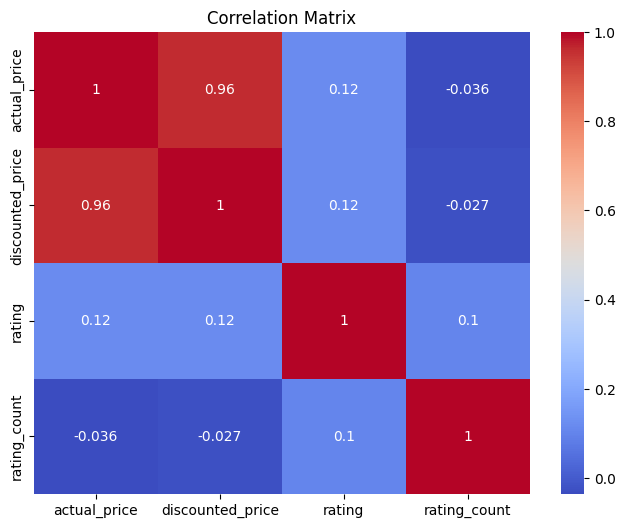

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# 15. Print total number of rows and columns

In [ ]:
print("Dataset Shape:", amazon_sales.shape)

Dataset Shape: (1465, 17)


# 16. Products Having Rating Above 4.5

In [ ]:
high_rated_products = amazon_sales[amazon_sales["rating"]>4.5]
high_rated_products[["product_name","rating"]]

,product_name,rating
137,"10k 8k 4k HDMI Cable, Certified 48Gbps 1ms Ult...",4.6
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,4.7
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0
447,Spigen EZ Fit Tempered Glass Screen Protector ...,4.6
459,Spigen EZ Fit Tempered Glass Screen Protector ...,4.7
468,Spigen EZ Fit Tempered Glass Screen Protector ...,4.6
571,"WeCool S5 Long Selfie Stick, with Large Reinfo...",4.6
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
820,Redgear MP35 Speed-Type Gaming Mousepad (Black...,4.6


# 17. Products with More Than 50,000 Reviews

In [ ]:
popular_products = amazon_sales[amazon_sales["rating_count"]>50000]
popular_products[["product_name","rating_count"]]

,product_name,rating_count
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,94363.0
8,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...",179691.0
11,boAt Rugged v3 Extra Tough Unbreakable Braided...,94363.0
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0
30,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,74976.0
...,...,...
1022,Pigeon by Stovekraft Amaze Plus Electric Kettl...,123365.0
1028,Pigeon Polypropylene Mini Handy and Compact Ch...,270563.0
1031,"Prestige Electric Kettle PKOSS - 1500watts, St...",63350.0
1032,Pigeon by Stovekraft Cruise 1800 watt Inductio...,54032.0


# 18. Relationship Between Rating and Review Count

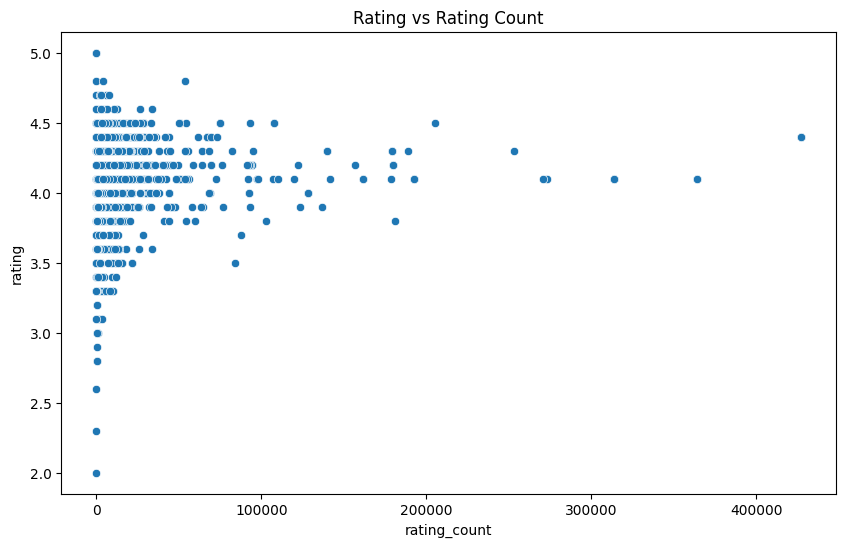

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=amazon_sales,
    x='rating_count',
    y='rating'
)

plt.title("Rating vs Rating Count")
plt.show()

# 19. Find missing values in each column

In [ ]:
amazon_sales.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,1465
rating,1
rating_count,2
about_product,0
user_id,0


# 20. Top Reviewed Products


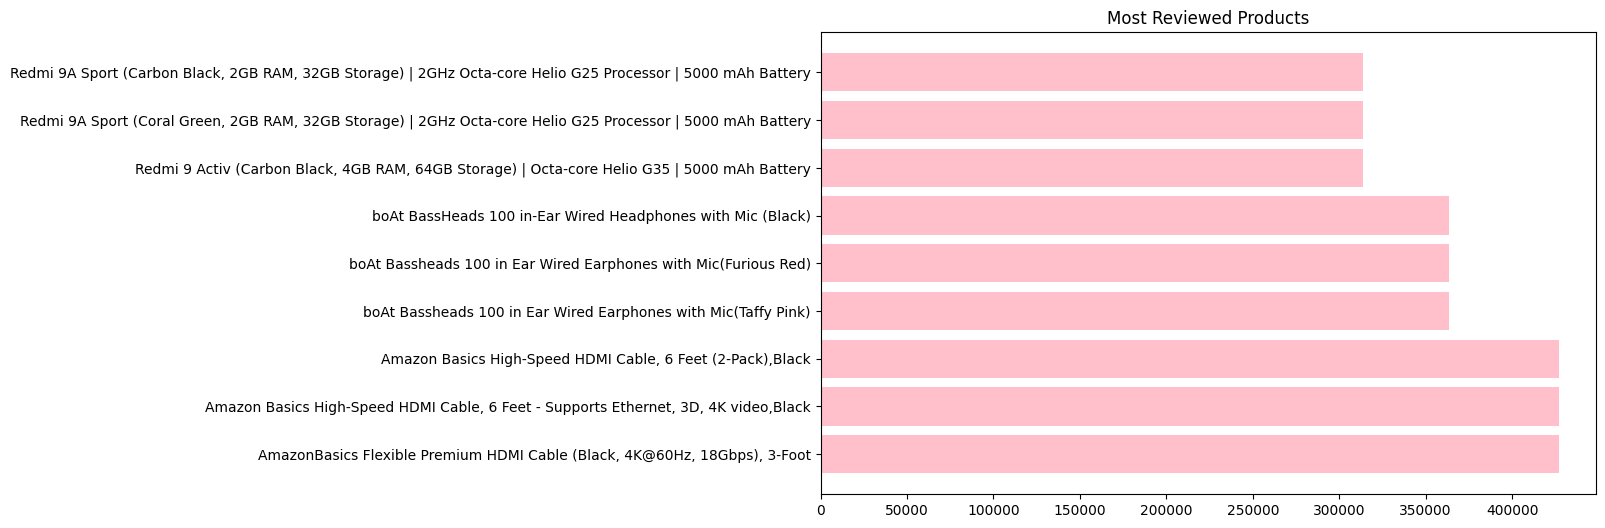

In [ ]:
top_reviewed = amazon_sales.nlargest(
    10,
    'rating_count'
)

plt.figure(figsize=(10,6))

plt.barh(
    top_reviewed['product_name'],
    top_reviewed['rating_count'],
    color="pink"
)

plt.title('Most Reviewed Products')

plt.show()